# Business Understanding
Dataset ini berisi data medis wanita Pima (setidaknya 21 tahun) dengan 8 fitur numerik dan 1 label biner:

0 → Tidak diabetes (negatif)

1 → Diabetes (positif)

Tujuan: memprediksi apakah seorang pasien menderita diabetes berdasarkan fitur-fitur tersebut.

# Data Understanding

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Describe The Data

### Melihat Ukuran Dataset

In [5]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 768
Jumlah Kolom : 9


### Melihat Nama Kolom

In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

### Melihat Tipe Data

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Statistik Deskriptif

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### Mengecek Jumlah Kelas Target

In [9]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

### Visualisasi Distribusi Target

C:\Users\LENOVO LOQ\AppData\Local\Temp\ipykernel_12732\1692123102.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


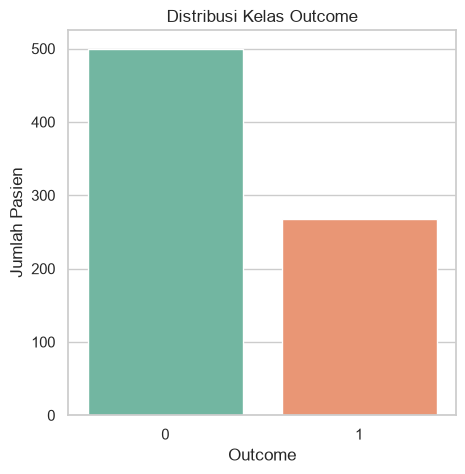

In [10]:
plt.figure(figsize=(5,5))

sns.countplot(
    x='Outcome',
    data=df,
    palette='Set2'
)

plt.title("Distribusi Kelas Outcome")
plt.xlabel("Outcome")
plt.ylabel("Jumlah Pasien")

plt.show()

## Explore Data (EDA)

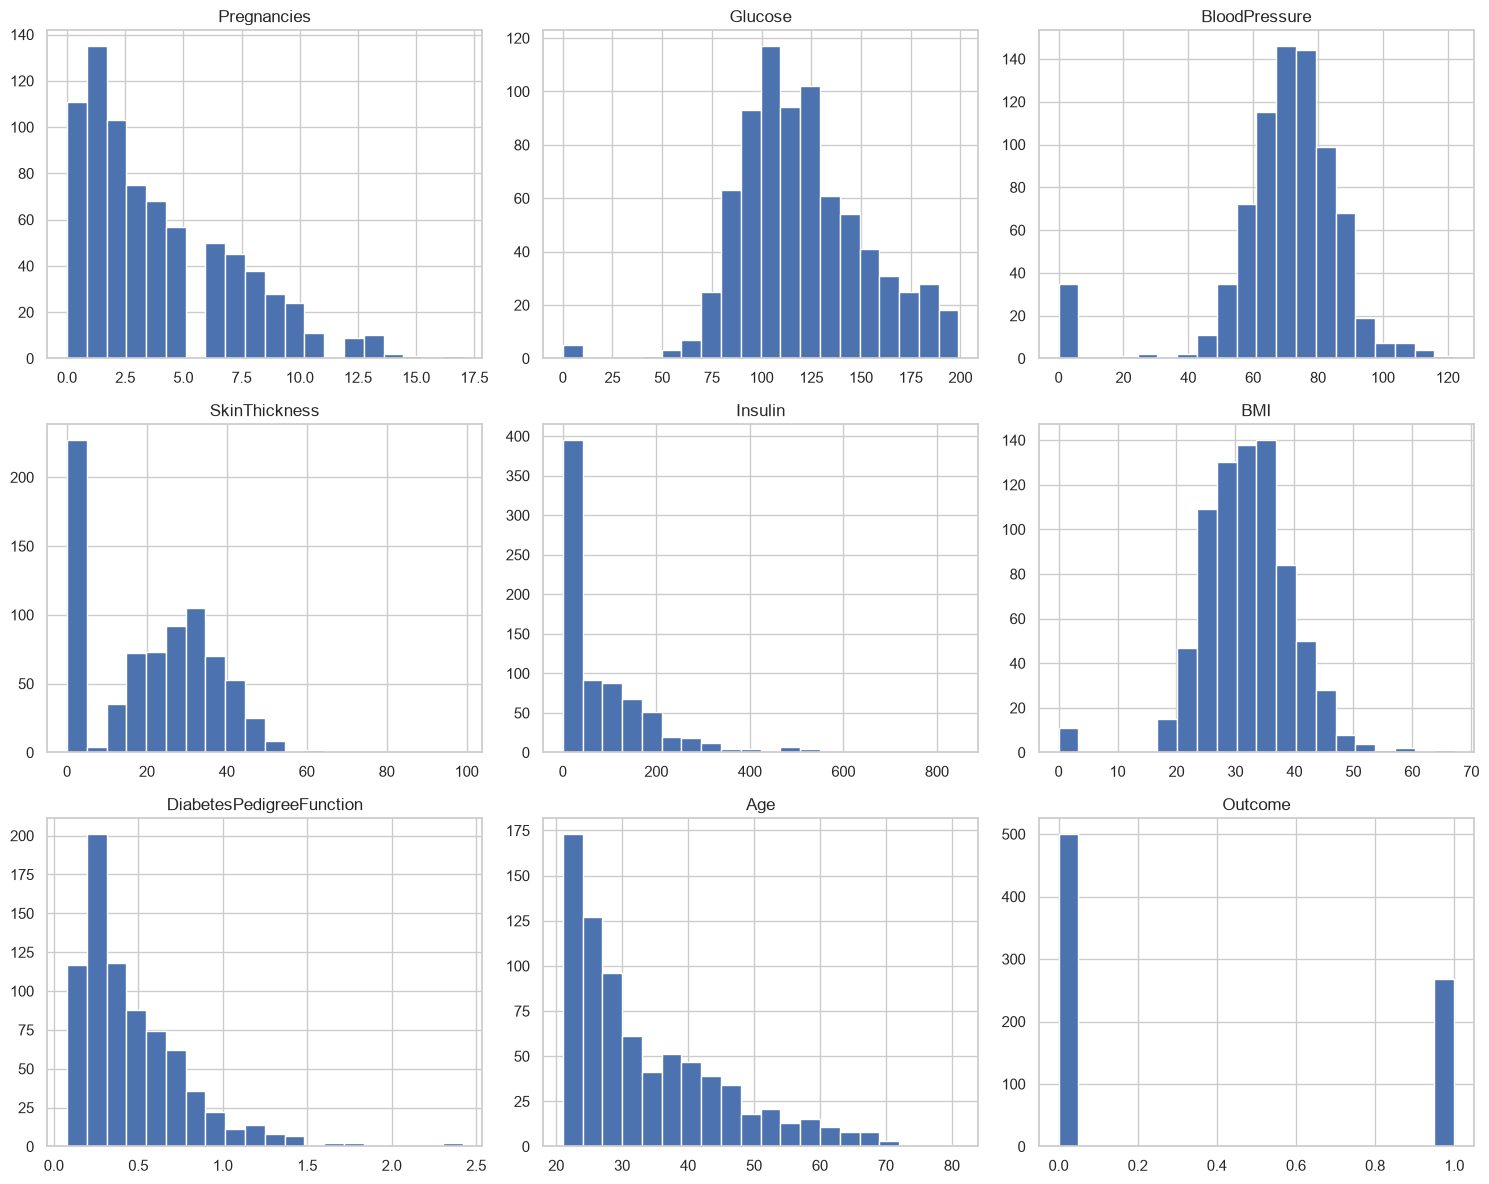

In [11]:
df.hist(figsize=(15,12), bins=20)

plt.tight_layout()

plt.show()

### BoxPlot

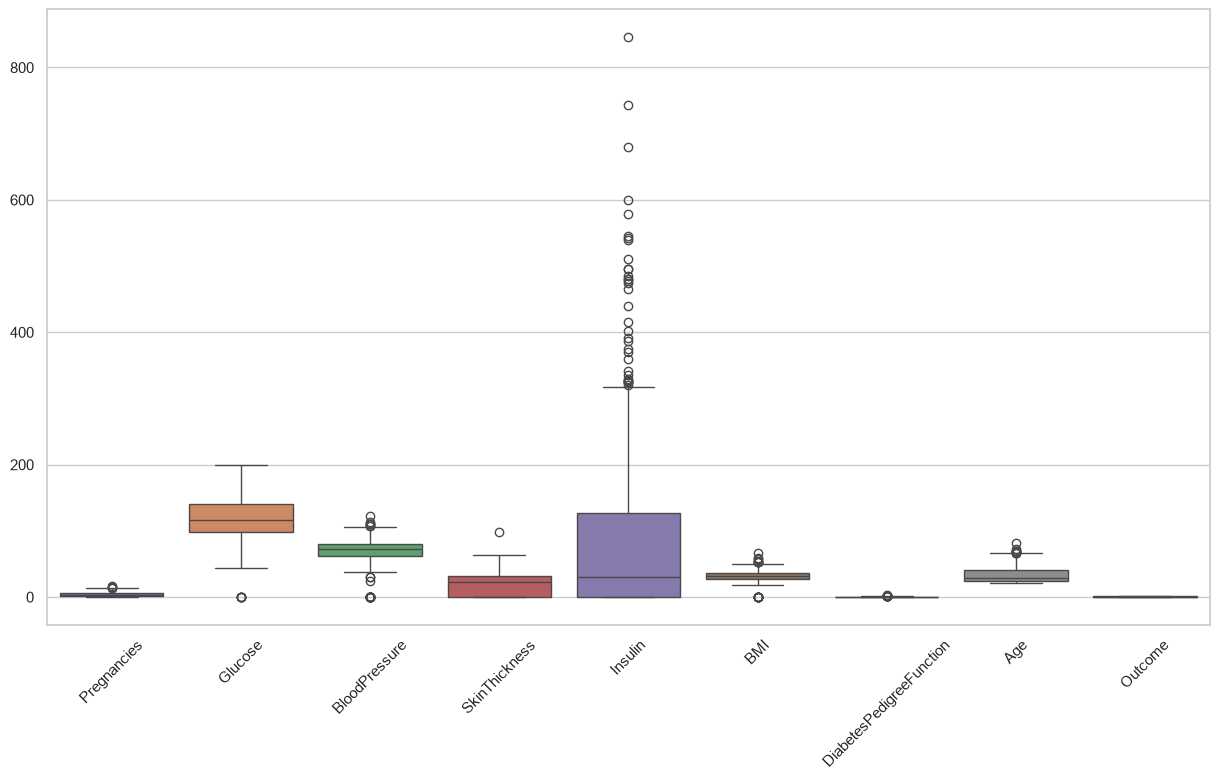

In [12]:
plt.figure(figsize=(15,8))

sns.boxplot(data=df)

plt.xticks(rotation=45)

plt.show()

### Korelasi

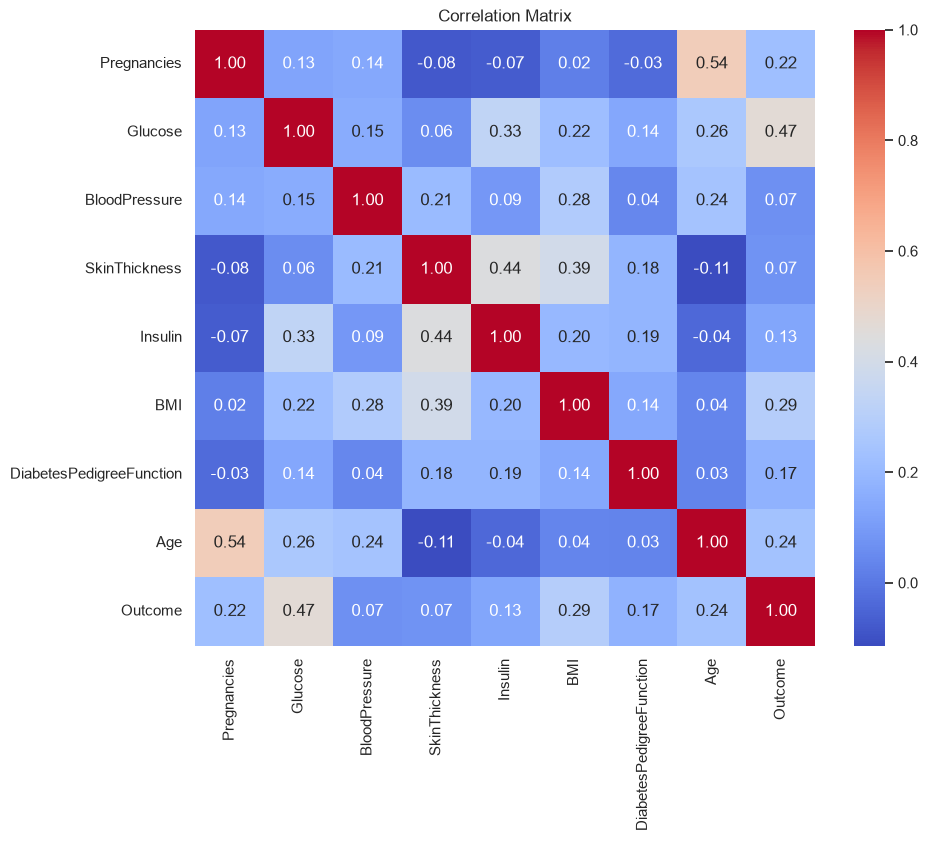

In [13]:
plt.figure(figsize=(10,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

### Hubungan Antar Variabel dengan Target

#### Glucose

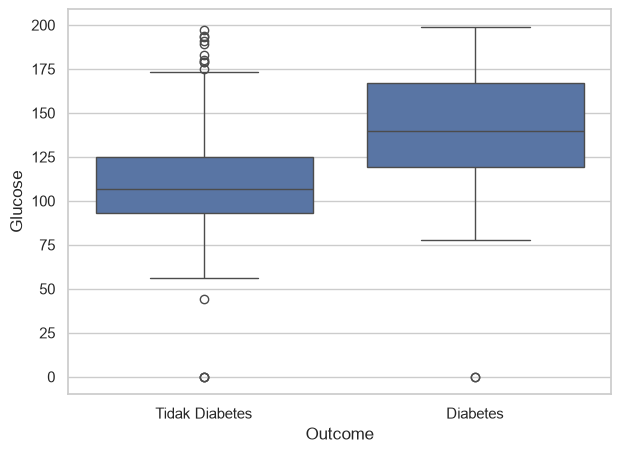

In [14]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='Glucose',
    data=df
)

plt.xticks([0,1],["Tidak Diabetes","Diabetes"])

plt.show()

#### BMI

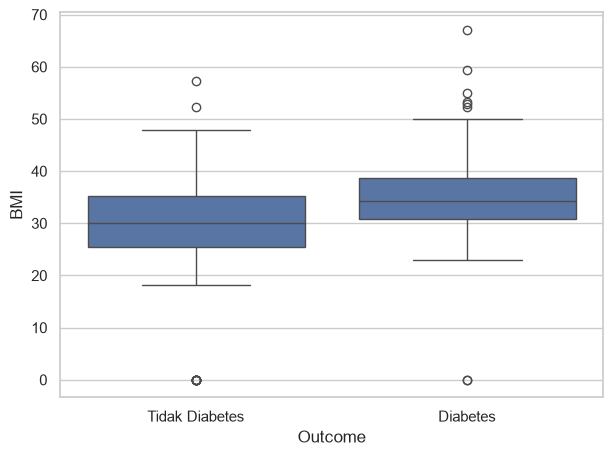

In [15]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='BMI',
    data=df
)

plt.xticks([0,1],["Tidak Diabetes","Diabetes"])

plt.show()

#### Age

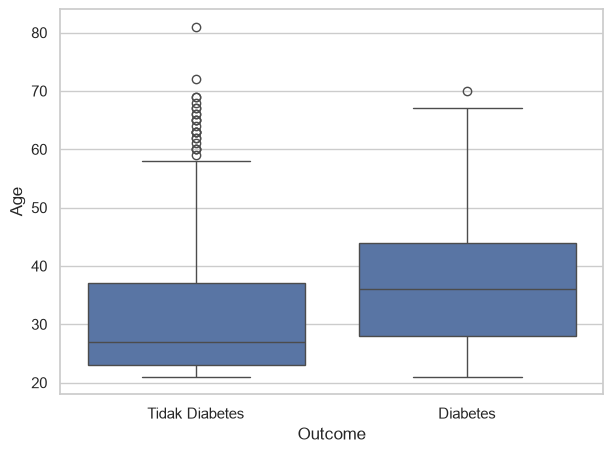

In [16]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='Age',
    data=df
)

plt.xticks([0,1],["Tidak Diabetes","Diabetes"])

plt.show()

#### Pregnancies

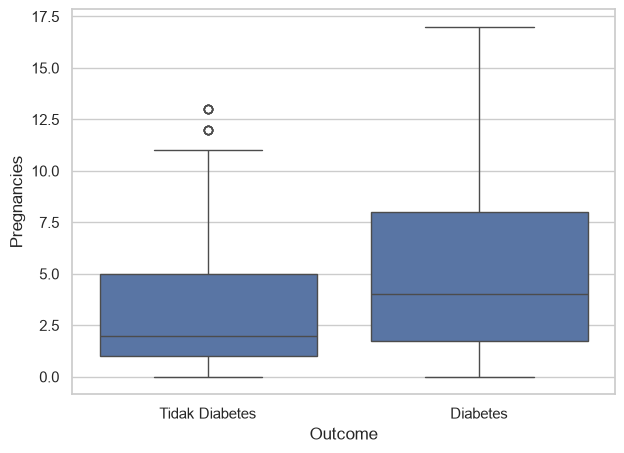

In [17]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x='Outcome',
    y='Pregnancies',
    data=df
)

plt.xticks([0,1],["Tidak Diabetes","Diabetes"])

plt.show()

#### PairPlot

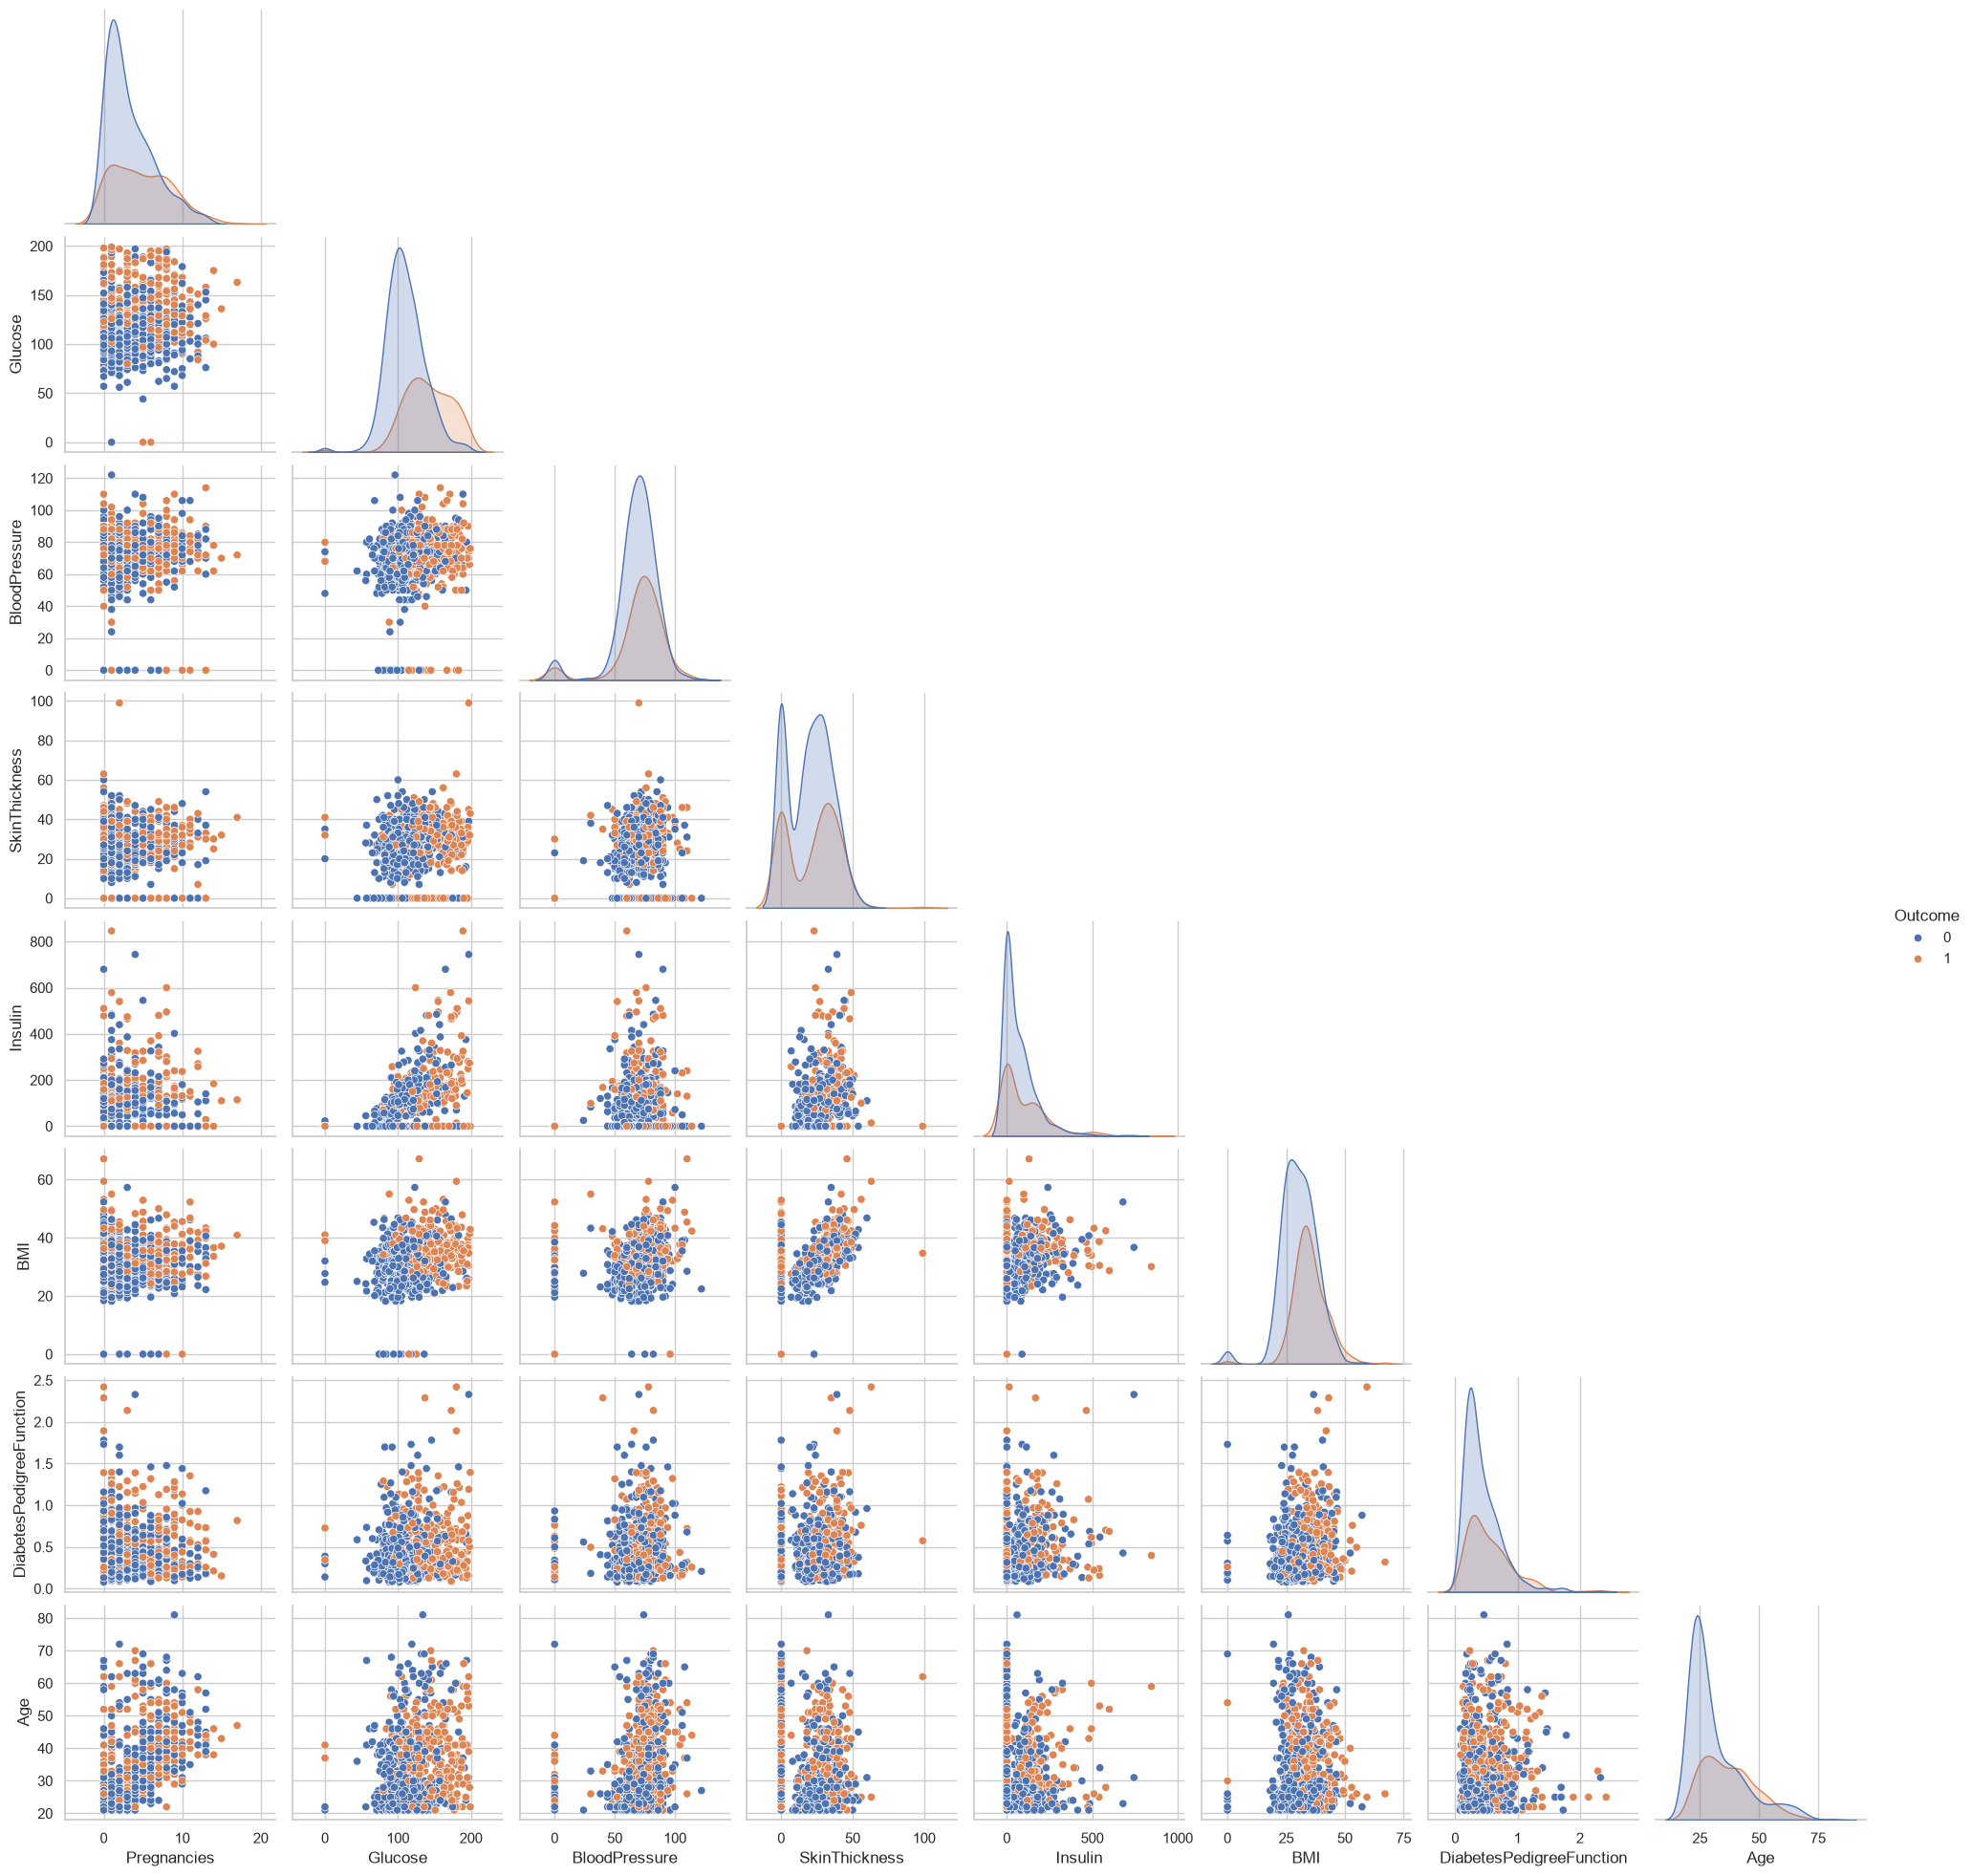

In [18]:
sns.pairplot(
    df,
    hue='Outcome',
    corner=True
)

plt.show()

## Verify Data Quality

### Mencari Missing Value

In [19]:
print("Missing value eksplisit:")
display(df.isnull().sum().to_frame("Missing"))

print("Jumlah duplikat:", df.duplicated().sum())

zero_check_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

zero_summary = pd.DataFrame({
    "Jumlah nilai 0": [(df[col] == 0).sum() for col in zero_check_columns]
}, index=zero_check_columns)

zero_summary


Missing value eksplisit:


,Missing
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Jumlah duplikat: 0


,Jumlah nilai 0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [20]:
data = df.copy()

missing_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

data[missing_columns] = data[missing_columns].replace(0, np.nan)

print("Missing value setelah 0 → NaN:")
display(data.isnull().sum().to_frame("Missing"))


Missing value setelah 0 → NaN:


,Missing
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [24]:
X = data.drop(columns="Outcome")
y = data["Outcome"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())


Shape X: (768, 8)
Shape y: (768,)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [27]:
from sklearn.model_selection import train_test_split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

split_distribution = pd.DataFrame({
    "Train": y_train.value_counts().sort_index(),
    "Test": y_test.value_counts().sort_index()
})
split_distribution.index = ["Tidak Diabetes (0)", "Diabetes (1)"]
split_distribution


X_train: (614, 8)
X_test : (154, 8)


,Train,Test
Tidak Diabetes (0),400,100
Diabetes (1),214,54


In [32]:
pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

pipeline_lr


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accou

In [33]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    pipeline_lr,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

fold_results = pd.DataFrame({
    "Fold": range(1, 6),
    "Accuracy": cv_results["test_accuracy"],
    "Precision": cv_results["test_precision"],
    "Recall": cv_results["test_recall"],
    "F1": cv_results["test_f1"],
    "ROC_AUC": cv_results["test_roc_auc"]
})

fold_results.round(4)


,Fold,Accuracy,Precision,Recall,F1,ROC_AUC
0,1,0.7886,0.7931,0.5349,0.6389,0.8669
1,2,0.7886,0.7429,0.6047,0.6667,0.8395
2,3,0.8211,0.8621,0.5814,0.6944,0.8512
3,4,0.7805,0.7353,0.5814,0.6494,0.8485
4,5,0.7623,0.6857,0.5714,0.6234,0.8107


In [34]:
cv_summary = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Mean": [
        cv_results["test_accuracy"].mean(),
        cv_results["test_precision"].mean(),
        cv_results["test_recall"].mean(),
        cv_results["test_f1"].mean(),
        cv_results["test_roc_auc"].mean()
    ],
    "Std": [
        cv_results["test_accuracy"].std(),
        cv_results["test_precision"].std(),
        cv_results["test_recall"].std(),
        cv_results["test_f1"].std(),
        cv_results["test_roc_auc"].std()
    ]
})

cv_summary["Mean (%)"] = (cv_summary["Mean"] * 100).round(2)
cv_summary["Std (%)"] = (cv_summary["Std"] * 100).round(2)
cv_summary


,Metric,Mean,Std,Mean (%),Std (%)
0,Accuracy,0.788231,0.019057,78.82,1.91
1,Precision,0.763808,0.059773,76.38,5.98
2,Recall,0.574751,0.022728,57.48,2.27
3,F1-Score,0.654545,0.024423,65.45,2.44
4,ROC-AUC,0.843364,0.018550,84.34,1.85


In [35]:
from sklearn.model_selection import GridSearchCV

In [36]:
param_grid = {
    "logistic__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best Parameters :", grid_search.best_params_)
print(f"Best CV ROC-AUC : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


Best Parameters : {'logistic__C': 0.1}
Best CV ROC-AUC : 0.8444


In [37]:
grid_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_logistic__C", "mean_test_score", "std_test_score", "rank_test_score"]
].sort_values("rank_test_score")

grid_results.columns = ["C", "Mean CV ROC-AUC", "Std", "Rank"]
grid_results


,C,Mean CV ROC-AUC,Std,Rank
1,0.10,0.844387,0.016045,1
2,1.00,0.843364,0.018550,2
3,10.00,0.843304,0.018815,3
4,100.00,0.843304,0.018815,3
0,0.01,0.840386,0.012016,5


In [38]:
y_train_prob_cv = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_results = []

for threshold in np.arange(0.20, 0.71, 0.05):
    y_pred_threshold = (y_train_prob_cv >= threshold).astype(int)

    tn_t, fp_t, fn_t, tp_t = confusion_matrix(
        y_train,
        y_pred_threshold
    ).ravel()

    threshold_results.append({
        "Threshold": round(float(threshold), 2),
        "Accuracy": accuracy_score(y_train, y_pred_threshold),
        "Precision": precision_score(y_train, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_train, y_pred_threshold),
        "Specificity": tn_t / (tn_t + fp_t),
        "F1": f1_score(y_train, y_pred_threshold),
        "False_Negative": fn_t,
        "False_Positive": fp_t
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(3)


,Threshold,Accuracy,Precision,Recall,Specificity,F1,False_Negative,False_Positive
0,0.20,0.656,0.504,0.907,0.522,0.648,20,191
1,0.25,0.700,0.545,0.841,0.625,0.662,34,150
2,0.30,0.738,0.592,0.799,0.705,0.680,43,118
3,0.35,0.759,0.639,0.710,0.785,0.673,62,86
4,0.40,0.783,0.700,0.664,0.848,0.681,72,61
5,0.45,0.785,0.723,0.621,0.872,0.668,81,51
6,0.50,0.780,0.745,0.561,0.898,0.640,94,41
7,0.55,0.780,0.769,0.528,0.915,0.626,101,34
8,0.60,0.777,0.794,0.486,0.932,0.603,110,27
9,0.65,0.770,0.829,0.430,0.952,0.566,122,19


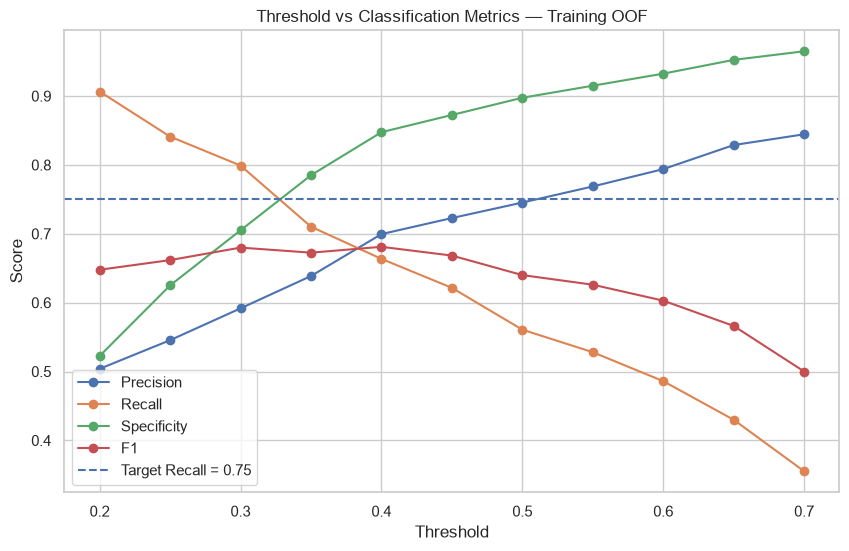

In [39]:
plt.figure(figsize=(10, 6))

for metric in ["Precision", "Recall", "Specificity", "F1"]:
    plt.plot(
        threshold_df["Threshold"],
        threshold_df[metric],
        marker="o",
        label=metric
    )

plt.axhline(0.75, linestyle="--", label="Target Recall = 0.75")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Classification Metrics — Training OOF")
plt.legend()
plt.show()


In [40]:
candidate_thresholds = threshold_df[
    threshold_df["Recall"] >= 0.75
].sort_values(
    by="F1",
    ascending=False
)

if candidate_thresholds.empty:
    raise ValueError("Tidak ada threshold yang memenuhi target Recall >= 0.75.")

best_threshold = float(candidate_thresholds.iloc[0]["Threshold"])

print("Kandidat threshold:")
display(candidate_thresholds.round(3))

print(f"Best Threshold berdasarkan aturan eksperimen: {best_threshold:.2f}")


Kandidat threshold:


,Threshold,Accuracy,Precision,Recall,Specificity,F1,False_Negative,False_Positive
2,0.30,0.738,0.592,0.799,0.705,0.680,43,118
1,0.25,0.700,0.545,0.841,0.625,0.662,34,150
0,0.20,0.656,0.504,0.907,0.522,0.648,20,191


Best Threshold berdasarkan aturan eksperimen: 0.30


In [41]:
# GridSearchCV sudah refit best estimator pada seluruh training set.
y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= best_threshold).astype(int)

cm_final = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm_final.ravel()

final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred, zero_division=0)
final_recall = recall_score(y_test, y_test_pred)
final_specificity = tn / (tn + fp)
final_f1 = f1_score(y_test, y_test_pred)
final_auc = roc_auc_score(y_test, y_test_prob)

final_evaluation = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall / Sensitivity",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_specificity,
        final_f1,
        final_auc
    ]
})

final_evaluation["Percentage"] = (
    final_evaluation["Score"] * 100
).round(2)

final_evaluation


,Metric,Score,Percentage
0,Accuracy,0.727273,72.73
1,Precision,0.578947,57.89
2,Recall / Sensitivity,0.814815,81.48
3,Specificity,0.680000,68.00
4,F1-Score,0.676923,67.69
5,ROC-AUC,0.810370,81.04


In [42]:
print("Final Confusion Matrix:")
print(cm_final)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Tidak Diabetes", "Diabetes"],
        zero_division=0
    )
)


Final Confusion Matrix:
[[68 32]
 [10 44]]

TN: 68
FP: 32
FN: 10
TP: 44

Classification Report:

                precision    recall  f1-score   support

Tidak Diabetes       0.87      0.68      0.76       100
      Diabetes       0.58      0.81      0.68        54

      accuracy                           0.73       154
     macro avg       0.73      0.75      0.72       154
  weighted avg       0.77      0.73      0.73       154



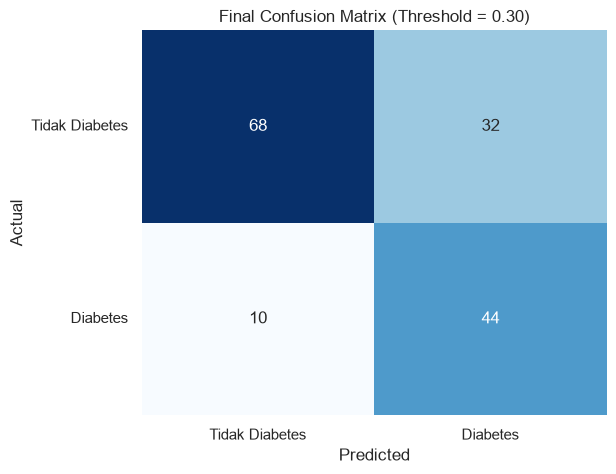

In [43]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)
plt.title(f"Final Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0.5, 1.5], ["Tidak Diabetes", "Diabetes"])
plt.yticks([0.5, 1.5], ["Tidak Diabetes", "Diabetes"], rotation=0)
plt.show()


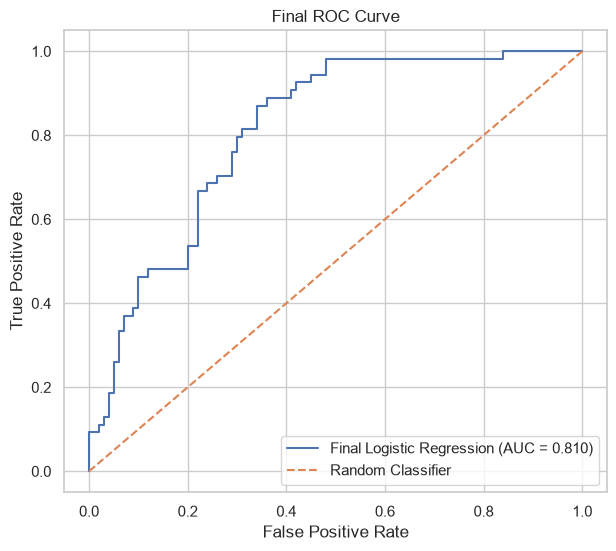

In [44]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Final Logistic Regression (AUC = {final_auc:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()


In [ ]:
baseline_test_pred = (y_test_prob >= 0.50).astype(int)
cm_baseline = confusion_matrix(y_test, baseline_test_pred)
tn_b, fp_b, fn_b, tp_b = cm_baseline.ravel()

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1",
        "False Negative",
        "False Positive"
    ],
    "Threshold 0.50": [
        accuracy_score(y_test, baseline_test_pred),
        precision_score(y_test, baseline_test_pred, zero_division=0),
        recall_score(y_test, baseline_test_pred),
        tn_b / (tn_b + fp_b),
        f1_score(y_test, baseline_test_pred),
        fn_b,
        fp_b
    ],
    f"Final Threshold {best_threshold:.2f}": [
        final_accuracy,
        final_precision,
        final_recall,
        final_specificity,
        final_f1,
        fn,
        fp
    ]
})

comparison


,Metric,Threshold 0.50,Final Threshold 0.30
0,Accuracy,0.688312,0.727273
1,Precision,0.565217,0.578947
2,Recall,0.481481,0.814815
3,Specificity,0.800000,0.680000
4,F1,0.520000,0.676923
5,False Negative,28.000000,10.000000
6,False Positive,20.000000,32.000000


In [48]:
logistic_model = best_model.named_steps["logistic"]

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coef_df["Odds_Ratio"] = np.exp(coef_df["Coefficient"])
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

coef_df


,Feature,Coefficient,Odds_Ratio,Abs_Coefficient
1,Glucose,1.019021,2.770482,1.019021
5,BMI,0.579880,1.785825,0.579880
0,Pregnancies,0.322040,1.379940,0.322040
6,DiabetesPedigreeFunction,0.210268,1.234009,0.210268
7,Age,0.157583,1.170678,0.157583
3,SkinThickness,0.067259,1.069573,0.067259
2,BloodPressure,-0.004054,0.995954,0.004054
4,Insulin,-0.003257,0.996748,0.003257


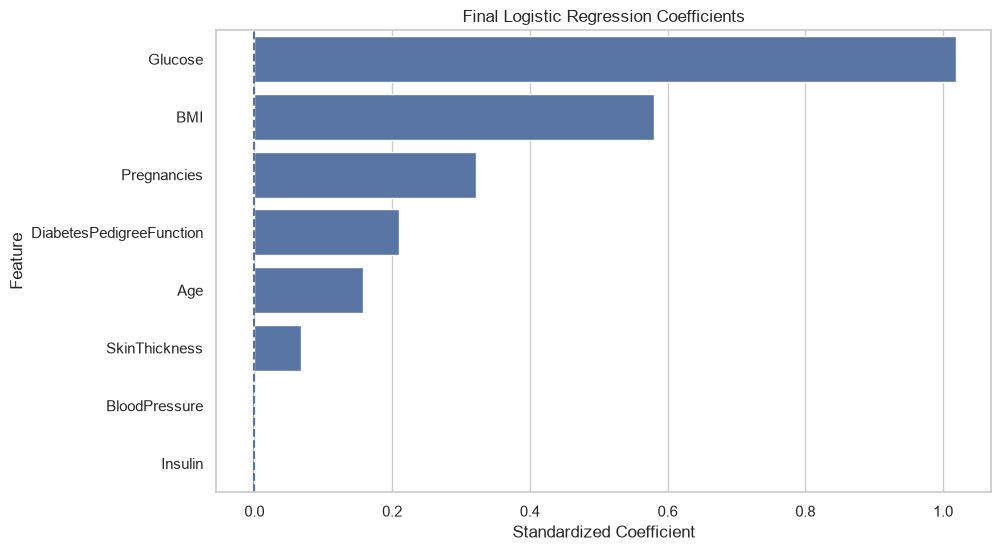

In [49]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    x="Coefficient",
    y="Feature"
)
plt.axvline(0, linestyle="--")
plt.title("Final Logistic Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("Feature")
plt.show()
